In [86]:
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from PIL import Image

from nuscenes.eval.detection.utils import category_to_detection_name
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import RadarPointCloud
from nuscenes.utils.geometry_utils import view_points
from nuscenes.utils.splits import create_splits_scenes

plt.style.use("seaborn-v0_8-whitegrid")

In [87]:
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "v1.0-mini"
assert DATA_ROOT.exists(), f"Dataset not found: {DATA_ROOT}"

In [88]:
# Load nuScenes-mini
nusc = NuScenes(
    version="v1.0-mini",
    dataroot=str(DATA_ROOT),
    verbose=False,
)


In [89]:
# Dataset summary
print(f"Dataset root:{DATA_ROOT}")
print(f"Scenes:{len(nusc.scene)}")
print(f"Keyframes:{len(nusc.sample)}")
print(f"Sensor records:{len(nusc.sample_data)}")
print(f"3D box occurrences:{len(nusc.sample_annotation)}")
print(f"Object instances:{len(nusc.instance)}")
print(f"Sensor channels:{len(nusc.sensor)}")

Dataset root:/Users/williamkuo/Desktop/imec/v1.0-mini
Scenes:10
Keyframes:404
Sensor records:31206
3D box occurrences:18538
Object instances:911
Sensor channels:12


## Data structure

```text
scene (~20 seconds)
└── sample (annotated keyframe at 2 Hz)
    ├── data[channel] -> sample_data -> sensor file
    │                              ├── calibrated_sensor
    │                              └── ego_pose
    └── anns -> sample_annotation -> instance/category/attributes
```

- `scene`: ~20 s driving sequence
- `sample`: annotated keyframe at 2 Hz
- `sample_data`: individual camera / radar / LiDAR measurement
- `sample_annotation`: 3D object annotation
- `samples/`: keyframe measurements
- `sweeps/`: intermediate sensor measurements

In [90]:
official_splits = create_splits_scenes()

# Create a mapping from scene token to scene name
scene_name_by_token = {
    scene["token"]: scene["name"]
    for scene in nusc.scene
}
# split the scenes into training and validation sets
scene_to_split = {
    scene_name: split_name
    for split_name in ("mini_train", "mini_val")
    for scene_name in official_splits[split_name]
}

In [91]:
# Sensor channels
sensor_df = pd.DataFrame([
    {
        "Channel": sensor["channel"],
        "Modality": sensor["modality"],
    }
    for sensor in nusc.sensor
])

display(sensor_df)

scene_df = pd.DataFrame([
    {
        "Scene": scene["name"],
        "Split": scene_to_split[scene["name"]],
        "Samples": scene["nbr_samples"],
        "Description": scene["description"],
    }
    for scene in nusc.scene
])

display(scene_df)


,Channel,Modality
0,CAM_FRONT,camera
1,CAM_BACK,camera
2,CAM_BACK_LEFT,camera
3,CAM_FRONT_LEFT,camera
4,CAM_FRONT_RIGHT,camera
5,CAM_BACK_RIGHT,camera
6,LIDAR_TOP,lidar
7,RADAR_FRONT,radar
8,RADAR_FRONT_RIGHT,radar
9,RADAR_FRONT_LEFT,radar


,Scene,Split,Samples,Description
0,scene-0061,mini_train,39,"Parked truck, construction, intersection, turn..."
1,scene-0103,mini_val,40,"Many peds right, wait for turning car, long bi..."
2,scene-0553,mini_train,41,"Wait at intersection, bicycle, large truck, pe..."
3,scene-0655,mini_train,41,"Parking lot, parked cars, jaywalker, bendy bus..."
4,scene-0757,mini_train,41,"Arrive at busy intersection, bus, wait at inte..."
5,scene-0796,mini_train,40,"Scooter, peds on sidewalk, bus, cars, truck, f..."
6,scene-0916,mini_val,41,"Parking lot, bicycle rack, parked bicycles, bu..."
7,scene-1077,mini_train,41,"Night, big street, bus stop, high speed, const..."
8,scene-1094,mini_train,40,"Night, after rain, many peds, PMD, ped with ba..."
9,scene-1100,mini_train,40,"Night, peds in sidewalk, peds cross crosswalk,..."


## data distribution

- original annotation category is more detailed therefore use only 10 classes as specified in the official repo

,Split,Scenes,Samples
0,mini_train,8,323
1,mini_val,2,81


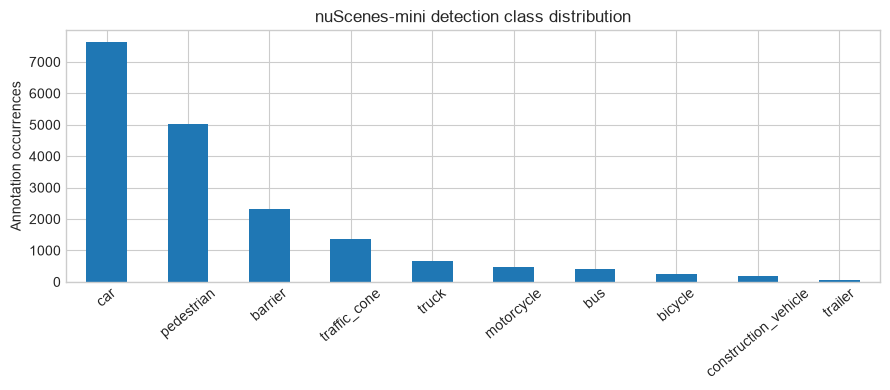

In [92]:
samples_per_split = Counter()
detection_class_counts = Counter()

for sample in nusc.sample:
    scene_name = scene_name_by_token[sample["scene_token"]]
    split = scene_to_split[scene_name]
    samples_per_split[split] += 1

    for ann_token in sample["anns"]:
        ann = nusc.get("sample_annotation", ann_token)
        cls = category_to_detection_name(ann["category_name"]) # map to 10 classes

        if cls is not None: # count the number of each class
            detection_class_counts[cls] += 1

split_df = pd.DataFrame({
    "Split": ["mini_train", "mini_val"],
    "Scenes": [
        len(official_splits["mini_train"]),
        len(official_splits["mini_val"]),
    ],
    "Samples": [
        samples_per_split["mini_train"],
        samples_per_split["mini_val"],
    ],
})

display(split_df)

class_counts = pd.Series(detection_class_counts).sort_values(ascending=False)

ax = class_counts.plot.bar(figsize=(9, 4))
ax.set_title("nuScenes-mini detection class distribution")
ax.set_ylabel("Annotation occurrences")
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

In [93]:
# calculate the distance from the ego vehicle to the annotation
def distance_from_ego(sample, ann):
    sd = nusc.get("sample_data", sample["data"]["LIDAR_TOP"])
    ego = nusc.get("ego_pose", sd["ego_pose_token"])

    return np.linalg.norm(
        np.array(ann["translation"][:2]) -
        np.array(ego["translation"][:2])
    )

## check the pedestrian information and specifically within the front view

In [94]:
pedestrian_records = [] # store the information of each pedestrian box in the front-view camera
frames_by_split = Counter()
frames_with_ped = Counter()

for sample in nusc.sample:
    scene = scene_name_by_token[sample["scene_token"]] # sample is from which scene
    split = scene_to_split[scene] # which split
    frames_by_split[split] += 1

    _, boxes, _ = nusc.get_sample_data(sample["data"]["CAM_FRONT"]) # only use the front-view camera
    ped_boxes = [
        box for box in boxes
        if category_to_detection_name(box.name) == "pedestrian"
    ]

    if ped_boxes:
        frames_with_ped[split] += 1

    for box in ped_boxes:
        ann = nusc.get("sample_annotation", box.token)
        distance = distance_from_ego(sample, ann)

        pedestrian_records.append({
            "sample_token": sample["token"],
            "split": split,
            "scene": scene,
            "instance": ann["instance_token"],
            "distance_m": distance,
            "lidar_pts": ann["num_lidar_pts"],
            "radar_pts": ann["num_radar_pts"],
        })

In [95]:
summary = []

for split in ("mini_train", "mini_val"):
    records = [r for r in pedestrian_records if r["split"] == split]
    no_radar = [r for r in records if r["radar_pts"] == 0]

    summary.append({
        "Split": split,
        "Frames": frames_by_split[split],
        "Frames with pedestrian": frames_with_ped[split],
        "Front pedestrian boxes": len(records),
        "Unique pedestrians": len({r["instance"] for r in records}),
        "No radar": f"{len(no_radar)} ({100 * len(no_radar) / len(records):.1f}%)",
        "Median distance": f"{np.median([r['distance_m'] for r in records]):.1f} m",
    })

display(pd.DataFrame(summary))

,Split,Frames,Frames with pedestrian,Front pedestrian boxes,Unique pedestrians,No radar,Median distance
0,mini_train,323,168,835,80,716 (85.7%),33.7 m
1,mini_val,81,50,299,43,244 (81.6%),25.5 m


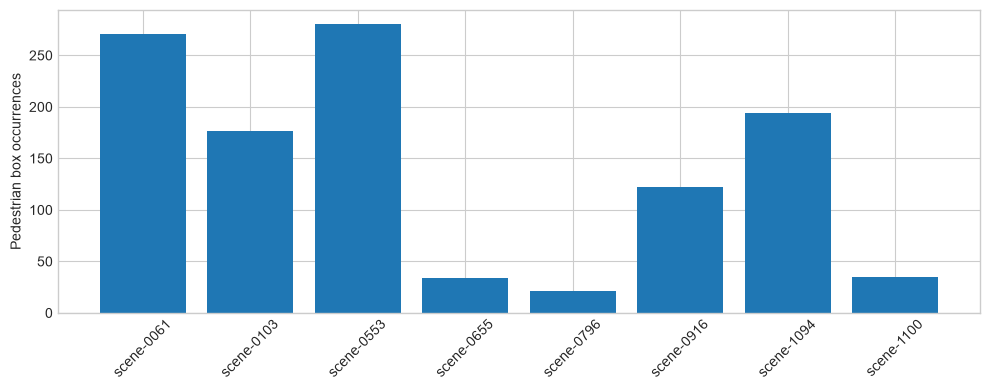

In [96]:
scene_counts = Counter(r["scene"] for r in pedestrian_records)

plt.figure(figsize=(10, 4))
plt.bar(scene_counts.keys(), scene_counts.values())
plt.ylabel("Pedestrian box occurrences")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

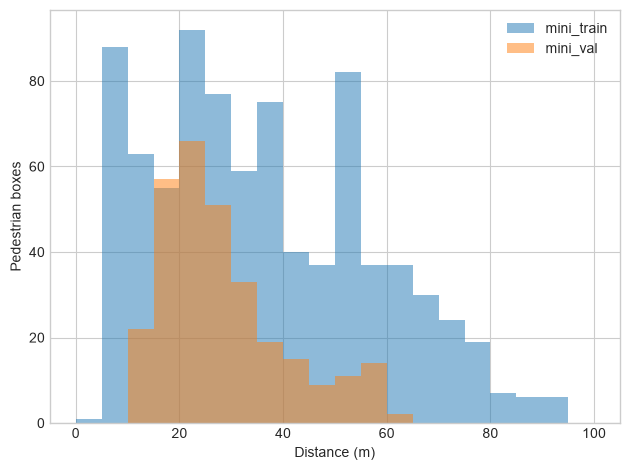

In [97]:
# Distance distribution
for split in ("mini_train", "mini_val"):
    distances = [
        r["distance_m"]
        for r in pedestrian_records
        if r["split"] == split
    ]
    plt.hist(distances, bins=np.arange(0, 101, 5), alpha=0.5, label=split)

plt.xlabel("Distance (m)")
plt.ylabel("Pedestrian boxes")
plt.legend()
plt.tight_layout()
plt.show()

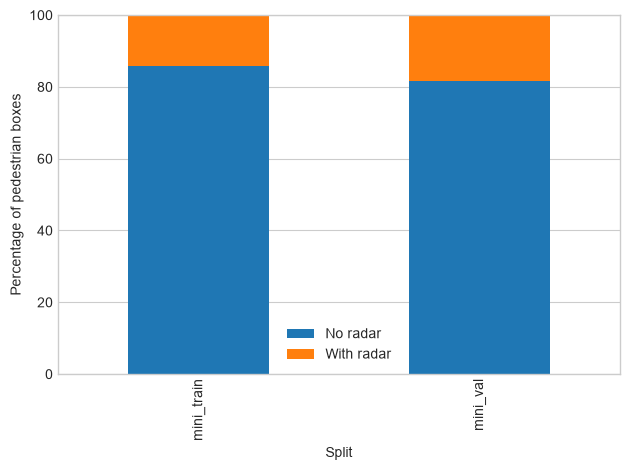

In [98]:
radar_stats = []

for split in ("mini_train", "mini_val"):
    records = [
        r for r in pedestrian_records
        if r["split"] == split
    ]

    no_radar = sum(r["radar_pts"] == 0 for r in records)

    radar_stats.append({
        "Split": split,
        "No radar": 100 * no_radar / len(records),
        "With radar": 100 * (len(records) - no_radar) / len(records),
    })

radar_df = pd.DataFrame(radar_stats).set_index("Split")
radar_df.plot.bar(stacked=True)

plt.ylabel("Percentage of pedestrian boxes")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## Findings that affect model design
1. The effective dataset is much smaller than the raw annotation count
The 5,015 pedestrian annotations in mini cover 360° and repeated time steps. For the chosen front-view task there are 835 train and 299 validation box occurrences, representing only 80 and 43 unique instances. All front-view pedestrian boxes are retained for training and evaluation, including pedestrians without LiDAR or Radar returns. The small number of unique instances still makes a pretrained, partly frozen camera encoder more appropriate than training a large model from scratch.

2. Scene imbalance makes random frame splitting invalid
A few scenes contain most front-view pedestrian boxes, while some scenes contain none. Adjacent keyframes also repeat the same object instances. Randomly splitting frames would leak near-identical images and people across train and validation. The official scene split is mandatory.

3. Radar is missing for most pedestrian boxes
Across all visible front-view pedestrians, 85.7% of train and 81.6% of validation boxes have num_radar_pts == 0. This field sums points across all radar sensors and applies no invalid-point filtering, so RADAR_FRONT alone is at least as sparse. Fusion must therefore tolerate missing radar evidence rather than assuming every target has a radar return.

4. Train and validation are not identically distributed
The median front-view pedestrian distance is 33.7 m in train and 25.5 m in validation. Mini contains only two validation scenes, both rich in pedestrians. Metrics will have high variance and must be presented as proof-of-concept results rather than large-scale generalization.

Modeling consequences:

- Use a pretrained lightweight camera backbone.
- Aggregate several radar sweeps and include time lag as a feature.
- Use gated fusion or cross-attention with an explicit radar-validity/occupancy channel.
- Include a camera-only baseline and a single-sweep vs multi-sweep ablation.
- Report performance by distance and visibility, not only one aggregate AP value.


# Sample-level visualization

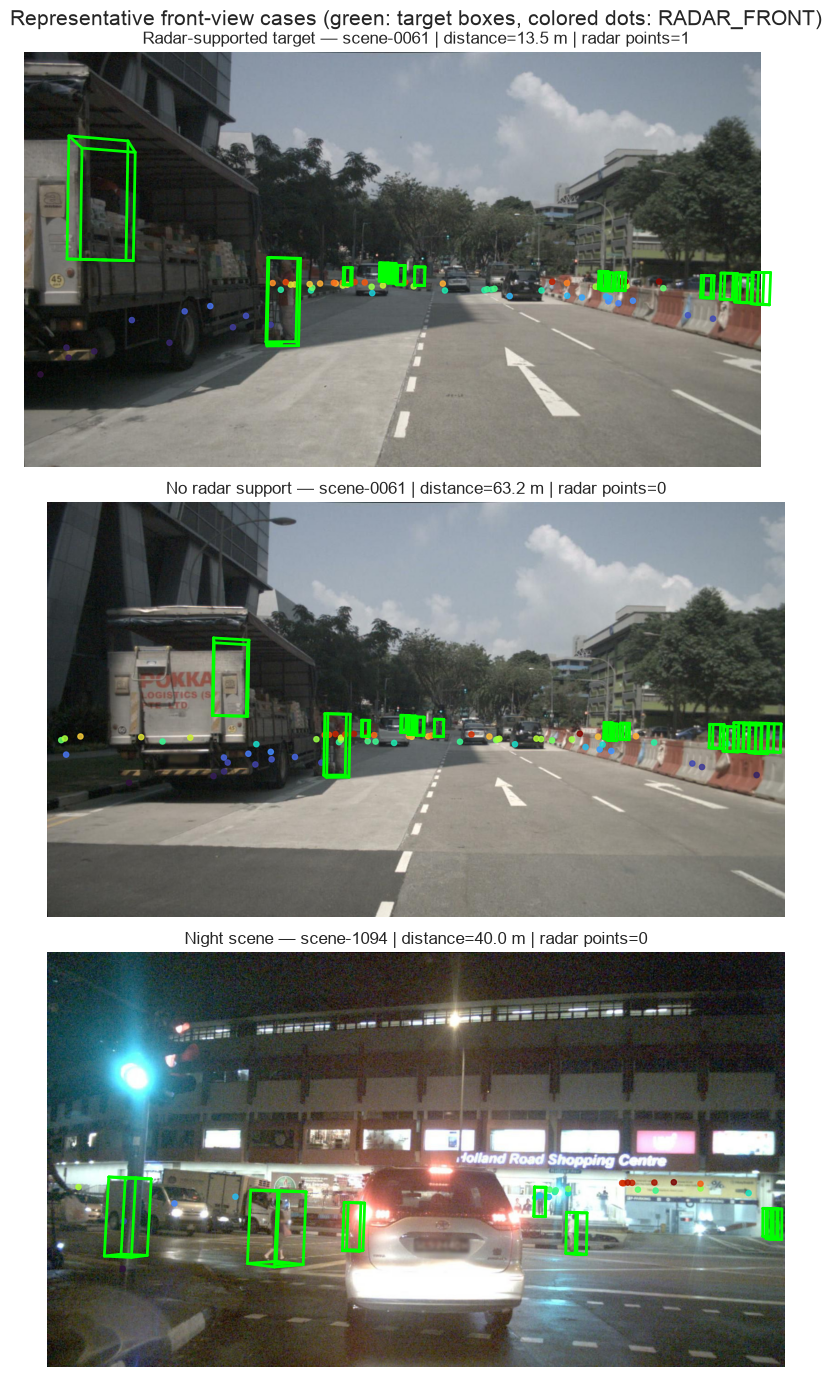

In [99]:
def draw_target_boxes(ax, sample):
    """
    Draw all visible pedestrian boxes on the CAM_FRONT image.
    """
    camera_token = sample["data"]["CAM_FRONT"]
    _, boxes, camera_intrinsic = nusc.get_sample_data(camera_token)

    for box in boxes:
        # Keep only pedestrian boxes
        if category_to_detection_name(box.name) != "pedestrian":
            continue

        box.render(
            ax,
            view=np.asarray(camera_intrinsic),
            normalize=True,
            colors=("lime", "lime", "lime"),
        )

# Overlay RADAR_FRONT points and pedestrian boxes on CAM_FRONT
def render_camera_radar_sample(ax, record, title):
    sample = nusc.get("sample", record["sample_token"])
    camera_token = sample["data"]["CAM_FRONT"]
    radar_token = sample["data"]["RADAR_FRONT"]
    points, depth, image = nusc.explorer.map_pointcloud_to_image(radar_token, camera_token) # map the radar point cloud to the image

    ax.imshow(image)
    ax.scatter(points[0], points[1], c=depth, cmap="turbo", s=14, alpha=0.85)
    draw_target_boxes(ax, sample)
    ax.set_title(title)
    ax.axis("off")

# Pedestrian with annotation-level radar support
supported = next(
    r for r in pedestrian_records
    if r["split"] == "mini_train"
    and r["radar_pts"] > 0
)

# Pedestrian without annotation-level radar support
unsupported = next(
    r for r in pedestrian_records
    if r["split"] == "mini_train"
    and r["radar_pts"] == 0
)

# Example from a night scene
night = next(
    r for r in pedestrian_records
    if r["scene"] in {"scene-1094", "scene-1100"}
)

cases = [
    (supported, f'Radar-supported target — {supported["scene"]}'),
    (unsupported, f'No radar support — {unsupported["scene"]}'),
    (night, f'Night scene — {night["scene"]}'),
]

fig, axes = plt.subplots(3, 1, figsize=(15, 14))
for ax, (record, title) in zip(axes, cases):
    render_camera_radar_sample(
        ax,
        record,
        (
            f'{title} | '
            f'distance={record["distance_m"]:.1f} m | '
            f'radar points={record["radar_pts"]}'
        ),
    )
fig.suptitle("Representative front-view cases (green: target boxes, colored dots: RADAR_FRONT)", fontsize=15)
fig.tight_layout()
plt.show()

## explore adding sweep radar data

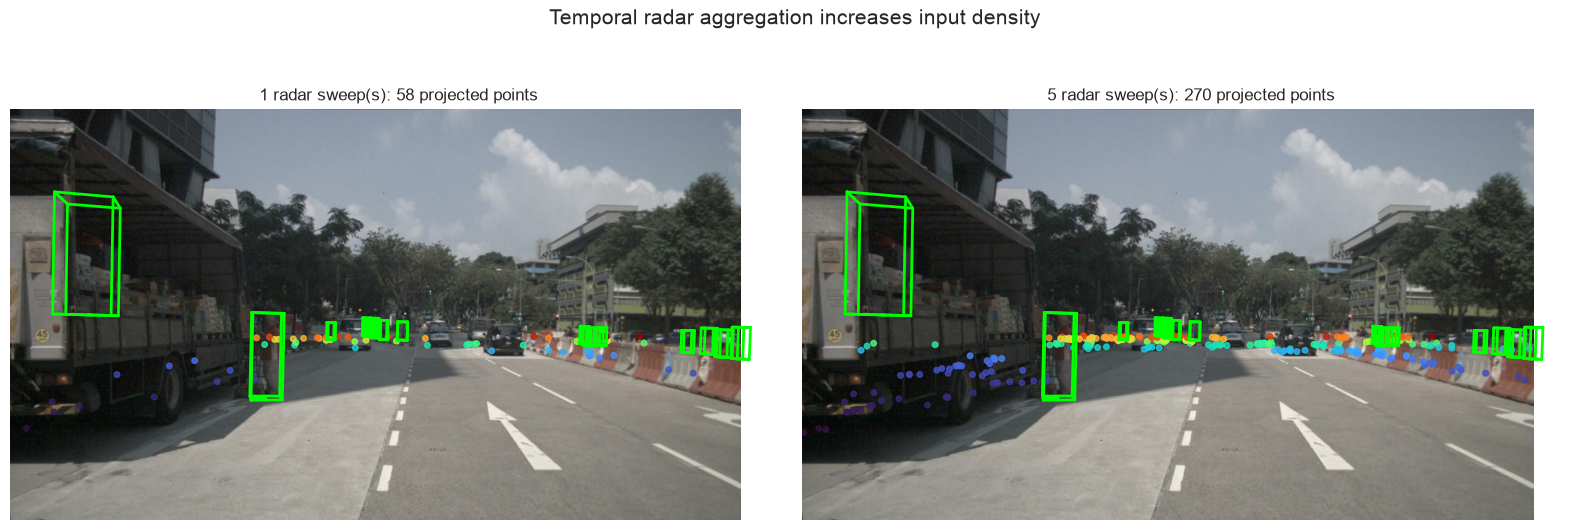

In [100]:
def project_front_radar_multisweep(sample, nsweeps):
    # Retrieve data from RADAR_FRONT, not just for the current sweep, but aggregate from previous sweeps as well
    radar, time_lags = RadarPointCloud.from_file_multisweep(
        nusc=nusc,
        sample_rec=sample,
        chan="RADAR_FRONT",
        ref_chan="CAM_FRONT",
        nsweeps=nsweeps,
        min_distance=1.0,
    )

    camera_record = nusc.get("sample_data", sample["data"]["CAM_FRONT"])
    calibration = nusc.get("calibrated_sensor", camera_record["calibrated_sensor_token"])
    camera_intrinsic = np.asarray(calibration["camera_intrinsic"], dtype=float)
    pixels = view_points(radar.points[:3], camera_intrinsic, normalize=True)
    depth = radar.points[2]

    # Filter out unwanted points
    mask = (
        (depth > 1.0)
        & (pixels[0] >= 0)
        & (pixels[0] < camera_record["width"])
        & (pixels[1] >= 0)
        & (pixels[1] < camera_record["height"])
    )

    image_path = Path(nusc.dataroot) / camera_record["filename"]
    return Image.open(image_path), pixels[:, mask], depth[mask], time_lags[:, mask]

comparison_sample = nusc.get("sample", supported["sample_token"])
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Compare radar sweeps with different sampling counts
for ax, nsweeps in zip(axes, (1, 5)):
    image, pixels, depth, time_lags = project_front_radar_multisweep(comparison_sample, nsweeps)
    ax.imshow(image)
    ax.scatter(pixels[0], pixels[1], c=depth, cmap="turbo", s=16, alpha=0.8)
    draw_target_boxes(ax, comparison_sample)
    ax.set_title(f"{nsweeps} radar sweep(s): {pixels.shape[1]} projected points")
    ax.axis("off")

fig.suptitle("Temporal radar aggregation increases input density", fontsize=15)
fig.tight_layout()
plt.show()

## EDA Final Summary

Dataset:

- nuScenes-mini: 10 scenes, 404 annotated keyframes
- `mini_train`: 8 scenes, 323 frames
- `mini_val`: 2 scenes, 81 frames
- Must use scene split, not random frame split, otherwise adjacent images and the same pedestrians will cause data leakage

Pedestrian:

- Total 360° pedestrian annotations: 5,015
- Visible to `CAM_FRONT`:
  - Train: 835 boxes, 80 unique instances
  - Validation: 299 boxes, 43 unique instances
- All visible front-view pedestrian boxes are retained for training and evaluation, including targets without LiDAR or Radar returns

Radar:

- Visible front-view pedestrians with no annotation-level Radar points:
  - Train: 85.7%
  - Validation: 81.6%
- In the example, radar is aggregated from 1 sweep to 5 sweeps, resulting in projected points increasing from 58 to 270
- Therefore, the model cannot rely on every pedestrian having radar data and must maintain a camera-only prediction path

Dataset limitations:

- The mini dataset is very small, validation contains only two scenes
- The distance distribution for train/validation differs:
  - Train median: 33.7 m
  - Validation median: 25.5 m
- Significant scene imbalance
- Suitable for proof-of-concept, not for claiming benchmark-level generalization

Final task definition:

```text
Input:
CAM_FRONT
+ RADAR_FRONT
+ 5 radar sweeps

Output:
Front-view 2D pedestrian boxes

Evaluation:
All pedestrians visible in CAM_FRONT

LiDAR:
Not a model input
Only used for dataset understanding, not target filtering
```
